### Carga de archivos .parquet y análisis de distribución de servicios

Se han encontrado 7 archivos Parquet.
¡Hecho! Dataset total con 1,916,757 registros cargados.

--- CLASES DETECTADAS (8) ---
Clase 0: Benigno -> 958,109 registros
Clase 1: Credential Access -> 871,188 registros
Clase 2: Defense Evasion -> 6,048 registros
Clase 3: Exfiltration -> 559 registros
Clase 4: Initial Access -> 10,662 registros
Clase 5: Persistence -> 6,048 registros
Clase 6: Privilege Escalation -> 6,048 registros
Clase 7: Reconnaissance -> 58,095 registros

--- DISTRIBUCIÓN GLOBAL ---
             Cantidad  Porcentaje (%)
service                              
dns            879490           45.88
ssl            860606           44.90
desconocido    154477            8.06
http             9847            0.51
ntp              6628            0.35


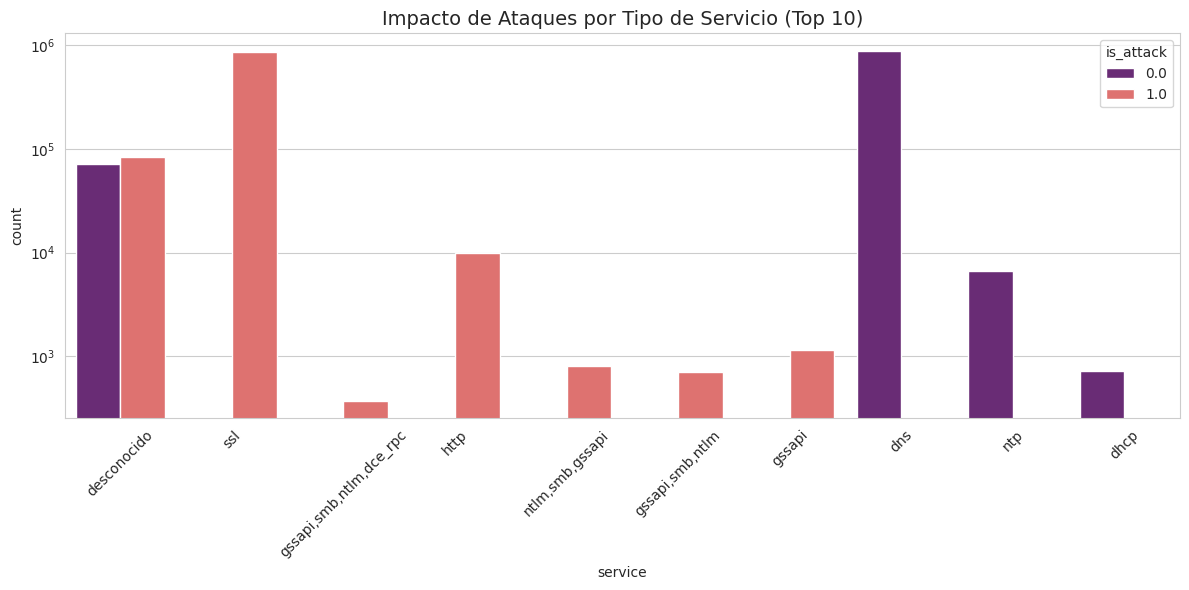

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. LOCALIZACIÓN Y CARGA
archivos_parquet = glob.glob("*.parquet")
print(f"Se han encontrado {len(archivos_parquet)} archivos Parquet.")

lista_df = []
for f in archivos_parquet:
    # Añadimos las columnas numéricas que Zeek nos da para las Edge Features
    columnas_interes = ['service', 'label_tactic', 'src_ip_zeek', 'dest_ip_zeek', 
                        'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'conn_state', 'missed_bytes', 'ts']
    temp_df = pd.read_parquet(f, columns=columnas_interes)
    lista_df.append(temp_df)

df = pd.concat(lista_df, ignore_index=True)
print(f"¡Hecho! Dataset total con {len(df):,} registros cargados.")

# 2. LIMPIEZA Y CODIFICACIÓN DE ETIQUETAS MULTICLASE
df['service'] = df['service'].replace(['-', ''], 'desconocido').fillna('desconocido')
df['is_attack'] = (df['label_tactic'].fillna('none').str.lower() != 'none').astype(float)

# Limpiamos los nulos y asignamos 'Benigno' a lo que no es ataque
df['label_tactic'] = df['label_tactic'].fillna('Benigno').replace(['none', '-'], 'Benigno')

# Codificamos las tácticas a números (0, 1, 2...)
encoder_tactics = LabelEncoder()
df['target_class'] = encoder_tactics.fit_transform(df['label_tactic'])

num_clases = len(encoder_tactics.classes_)
print(f"\n--- CLASES DETECTADAS ({num_clases}) ---")
for i, clase in enumerate(encoder_tactics.classes_):
    print(f"Clase {i}: {clase} -> {len(df[df['target_class'] == i]):,} registros")

# 3. DIAGNÓSTICO
resumen = pd.DataFrame({
    'Cantidad': df['service'].value_counts(),
    'Porcentaje (%)': (df['service'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- DISTRIBUCIÓN GLOBAL ---")
print(resumen.head())

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
top_10 = df['service'].value_counts().head(10).index
df_plot = df[df['service'].isin(top_10)]

sns.countplot(data=df_plot, x='service', hue='is_attack', palette='magma')
plt.title('Impacto de Ataques por Tipo de Servicio (Top 10)', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Engineering (Nodos Inductivos y Aristas)

Para que el modelo sea verdaderamente inductivo y agnóstico a la IP, las características iniciales de los nodos (X) deben ser estadísticas de comportamiento.

In [65]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("1. Procesando Características de las Aristas (Edge Features Avanzadas)...")

# --- INGENIERÍA DE CARACTERÍSTICAS TEMPORALES ---
print("Calculando delta temporal para detectar Persistencia (Beaconing)...")
# Ordenamos por IP Origen, IP Destino y Timestamp (ts)
df = df.sort_values(by=['src_ip_zeek', 'dest_ip_zeek', 'ts'])
# Calculamos la diferencia de tiempo con la conexión inmediatamente anterior
df['time_since_last_conn'] = df.groupby(['src_ip_zeek', 'dest_ip_zeek'])['ts'].diff().fillna(0.0)

# 1. Añadimos variable temporal y missed_bytes
edge_cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'missed_bytes', 'time_since_last_conn']
df[edge_cols] = df[edge_cols].fillna(0)

# 2. One-Hot Encoding del estado de la conexión
df['conn_state'] = df['conn_state'].fillna('OTH')
conn_state_dummies = pd.get_dummies(df['conn_state'], prefix='state').astype(float)

# 3. Concatenamos numéricas y categóricas
edge_features_df = pd.concat([df[edge_cols], conn_state_dummies], axis=1)

# 4. Estandarizamos (vital porque la columna temporal puede tener valores muy dispares)
scaler_edges = StandardScaler()
edge_features_np = scaler_edges.fit_transform(edge_features_df.values)

print(f"-> Aristas procesadas. Nuevas dimensiones de Edge Features: {edge_features_np.shape[1]} columnas")
print("2. Procesando Características de los Nodos (Node Features Inductivas)...")
ips_unicas = pd.unique(df[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

# USO DE NAMED AGGREGATION (Soluciona el error de las columnas)
# Calculamos estadísticas cuando la IP actúa como ORIGEN (Out)
out_stats = df.groupby('src_ip_zeek').agg(
    out_bytes_mean=('orig_bytes', 'mean'),
    out_pkts_mean=('orig_pkts', 'mean'),
    out_degree=('orig_bytes', 'count') # El conteo de conexiones
)

# Calculamos estadísticas cuando la IP actúa como DESTINO (In)
in_stats = df.groupby('dest_ip_zeek').agg(
    in_bytes_mean=('resp_bytes', 'mean'),
    in_pkts_mean=('resp_pkts', 'mean'),
    in_degree=('resp_bytes', 'count')
)

node_df = pd.DataFrame(index=ips_unicas)
node_df = node_df.join(out_stats).join(in_stats).fillna(0)

scaler_nodes = StandardScaler()
node_features_np = scaler_nodes.fit_transform(node_df.values)

print(f"-> Nodos procesados con éxito: {len(ips_unicas):,}")

1. Procesando Características de las Aristas (Edge Features Avanzadas)...
Calculando delta temporal para detectar Persistencia (Beaconing)...
-> Aristas procesadas. Nuevas dimensiones de Edge Features: 14 columnas
2. Procesando Características de los Nodos (Node Features Inductivas)...
-> Nodos procesados con éxito: 357


### Construcción del Grafo en PyTorch

In [66]:
import torch

print("Construyendo matriz de adyacencia...")
# Codificamos las IPs a índices numéricos (0 a N)
encoder = LabelEncoder()
encoder.fit(ips_unicas)
df['src_id'] = encoder.transform(df['src_ip_zeek'])
df['dst_id'] = encoder.transform(df['dest_ip_zeek'])

# 1. Matriz de Adyacencia Global (edge_index) [2, num_aristas]
origen = torch.tensor(df['src_id'].values, dtype=torch.long)
destino = torch.tensor(df['dst_id'].values, dtype=torch.long)
edge_index_total = torch.stack([origen, destino], dim=0)

# 2. Tensores de Características (X) y Aristas (Edge_Attr)
x_nodos = torch.tensor(node_features_np, dtype=torch.float)
edge_attr_total = torch.tensor(edge_features_np, dtype=torch.float)

# 3. Etiquetas (Target multiclase)
# IMPORTANTE: CrossEntropyLoss requiere que las etiquetas sean 'long' (enteros)
y_total = torch.tensor(df['target_class'].values, dtype=torch.long)
edge_services = df['service'].values

print(f"Tensor X (Nodos): {x_nodos.shape}")
print(f"Tensor edge_index (Topología): {edge_index_total.shape}")

Construyendo matriz de adyacencia...
Tensor X (Nodos): torch.Size([357, 6])
Tensor edge_index (Topología): torch.Size([2, 1916757])


### Enrutador y Partición Estratificada Train/Test

In [67]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Estratificación
df['stratify_key'] = df['service'] + '_' + df['is_attack'].astype(int).astype(str)
conteo_clases = df['stratify_key'].value_counts()
clases_validas = conteo_clases[conteo_clases > 1].index

indices_validos = df.index[df['stratify_key'].isin(clases_validas)].tolist()
idx_train, idx_test = train_test_split(
    indices_validos, 
    test_size=0.20, 
    random_state=42, 
    stratify=df.loc[indices_validos, 'stratify_key']
)

train_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)
train_mask[idx_train] = True
test_mask[idx_test] = True

# 2. SEPARACIÓN DEL COMITÉ (Basado en el EDA)
servicios = df['service'].values
is_ataque = df['is_attack'].values

# Definimos 4 grupos lógicos ahora
mask_web = np.isin(servicios, ['ssl', 'http'])
mask_infra = np.isin(servicios, ['dns', 'ntp', 'dhcp'])
# NUEVO EXPERTO: Tráfico de Autenticación y Windows
mask_auth = np.isin(servicios, ['smb', 'gssapi', 'ntlm', 'dce_rpc', 'gssapi,smb,ntlm', 'smb,dce_rpc,ntlm,gssapi', 'ntlm,dce_rpc,smb,gssapi']) 
mask_gen = ~(mask_web | mask_infra | mask_auth) # El resto (desconocido, ftp, etc.)

# --- SOLUCIÓN A LA VARIANZA (El truco del Data Leakage) ---
# Como Web es 100% ataque, necesitamos inyectarle algunos benignos para entrenar.
# Como Infra es 100% benigno, necesitamos inyectarle ataques para entrenar.
# Tomaremos prestados ejemplos del grupo 'Generalista' que sí está balanceado.

benignos_disponibles = mask_gen & (is_ataque == 0)
ataques_disponibles = mask_gen & (is_ataque == 1)

# Máscaras de Entrenamiento para los Expertos (Inyección de varianza)
mask_train_web = (mask_web | benignos_disponibles)
mask_train_infra = (mask_infra | ataques_disponibles)
mask_train_auth = (mask_auth | benignos_disponibles) # Necesita ejemplos benignos

# Convertimos a tensores para PyTorch (Y aplicamos el split de train/test)
train_mask_web = torch.tensor(mask_train_web, dtype=torch.bool) & train_mask
train_mask_infra = torch.tensor(mask_train_infra, dtype=torch.bool) & train_mask
train_mask_auth = torch.tensor(mask_train_auth, dtype=torch.bool) & train_mask
train_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & train_mask

# --- UNDERSAMPLING PARA EL ENTRENAMIENTO ---
# Extraemos los índices donde hay Benigno (0) o Credential Access (1) EN EL CONJUNTO DE TRAIN
idx_mayoritarias = np.where(((is_ataque == 0) | (df['target_class'].values == 1)) & train_mask.numpy())[0]

# Decidimos cuántos queremos "apagar" (ej. descartamos el 75% para aligerar el ruido)
porcentaje_descarte = 0.75
num_descarte = int(len(idx_mayoritarias) * porcentaje_descarte)

# Elegimos aleatoriamente cuáles apagar
np.random.seed(42)
idx_a_apagar = np.random.choice(idx_mayoritarias, num_descarte, replace=False)

# Creamos un tensor de máscara de "apagado"
mascara_apagado = torch.zeros(len(df), dtype=torch.bool)
mascara_apagado[idx_a_apagar] = True

# Se lo restamos a los tensores de entrenamiento de los expertos
train_mask_web = train_mask_web & ~mascara_apagado
train_mask_infra = train_mask_infra & ~mascara_apagado
train_mask_auth = train_mask_auth & ~mascara_apagado
train_mask_gen = train_mask_gen & ~mascara_apagado

print(f"Undersampling aplicado: Se han silenciado {num_descarte:,} ejemplos mayoritarios para el entrenamiento.")

test_mask_web = torch.tensor(mask_web, dtype=torch.bool) & test_mask
test_mask_infra = torch.tensor(mask_infra, dtype=torch.bool) & test_mask
test_mask_auth = torch.tensor(mask_auth, dtype=torch.bool) & test_mask
test_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & test_mask

print("\n--- DISTRIBUCIÓN DEL COMITÉ PARA ENTRENAMIENTO ---")
print(f"Experto Web (con varianza inyectada): {train_mask_web.sum().item():,} aristas")
print(f"Experto Infra (con varianza inyectada): {train_mask_infra.sum().item():,} aristas")
print(f"Experto Generalista: {train_mask_gen.sum().item():,} aristas")

Undersampling aplicado: Se han silenciado 1,097,493 ejemplos mayoritarios para el entrenamiento.

--- DISTRIBUCIÓN DEL COMITÉ PARA ENTRENAMIENTO ---
Experto Web (con varianza inyectada): 191,236 aristas
Experto Infra (con varianza inyectada): 242,768 aristas
Experto Generalista: 80,039 aristas


### Arquitectura GraphSAGE (El Modelo)

In [68]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv

class AdvancedEdgeExpert(torch.nn.Module):
    def __init__(self, node_in_channels, edge_in_channels, hidden_channels, out_classes, conv_type='SAGE', dropout_rate=0.3):
        super(AdvancedEdgeExpert, self).__init__()
        self.conv_type = conv_type
        
        # --- DIVERSIDAD ARQUITECTÓNICA ---
        if conv_type == 'SAGE':
            self.conv1 = SAGEConv(node_in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, hidden_channels)
            self.conv3 = SAGEConv(hidden_channels, hidden_channels) # NUEVA CAPA
        elif conv_type == 'GAT':
            # GAT usa cabezales de atención (heads). Multiplican la salida, 
            # así que dividimos los canales para mantener la dimensión final igual.
            heads = 4
            self.conv1 = GATConv(node_in_channels, hidden_channels // heads, heads=heads)
            self.conv2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads) # AHORA MANTIENE HEADS
            self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1) # NUEVA CAPA FINAL

        
        # --- PERCEPTRÓN DINÁMICO ---
        clf_input_dim = (hidden_channels * 2) + edge_in_channels
        self.edge_classifier = nn.Sequential(
            nn.Linear(clf_input_dim, hidden_channels),
            nn.BatchNorm1d(hidden_channels), # Batch Normalization ayuda mucho a la convergencia
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, out_classes) 
        )

    def forward(self, x, edge_index_msg, edge_index_pred, edge_attr_pred):
        x = self.conv1(x, edge_index_msg)
        x = F.relu(x)
        x = self.conv2(x, edge_index_msg)
        x = F.relu(x)
        x = self.conv3(x, edge_index_msg)
        
        src = edge_index_pred[0]
        dst = edge_index_pred[1]
        
        edge_features = torch.cat([x[src], x[dst], edge_attr_pred], dim=-1)
        
        return self.edge_classifier(edge_features)

### Bucle de Entrenamiento (Experto Generalista)

In [69]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}\n")

# --- 1. INSTANCIAMOS LOS 4 MODELOS (EL COMITÉ) ---
# 1. EXPERTO WEB: Muchos datos, topología sencilla. 
# Usamos SAGE con alta capacidad (128 canales).
model_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 
                               hidden_channels=128, out_classes=num_clases, 
                               conv_type='SAGE', dropout_rate=0.3).to(device)

# 2. EXPERTO INFRAESTRUCTURA (DNS): Topología en estrella muy predecible.
# Reducimos los canales a 64 para evitar Overfitting y menos dropout.
model_infra = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 
                                 hidden_channels=64, out_classes=num_clases, 
                                 conv_type='SAGE', dropout_rate=0.2).to(device)

# 3. EXPERTO AUTENTICACIÓN: Clave para ataques laterales y tickets Kerberos.
# Usamos GAT (Atención) para que se fije en quién autentica a quién. 128 canales.
model_auth = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 
                                hidden_channels=128, out_classes=num_clases, 
                                conv_type='GAT', dropout_rate=0.4).to(device)

# 4. EXPERTO GENERALISTA: El todoterreno. El que se come los datos más raros y con más ruido.
# GAT, máximo tamaño de canales (256) y máximo dropout para forzar generalización.
model_gen = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 
                               hidden_channels=512, out_classes=num_clases, 
                               conv_type='GAT', dropout_rate=0.5).to(device)

# Optimizadores asimétricos (Los modelos más pesados aprenden mejor con LR más bajos)
opt_web = torch.optim.Adam(model_web.parameters(), lr=0.005)
opt_infra = torch.optim.Adam(model_infra.parameters(), lr=0.005)
opt_auth = torch.optim.Adam(model_auth.parameters(), lr=0.003)
opt_gen = torch.optim.Adam(model_gen.parameters(), lr=0.001) # Aprende más lento pero más seguro

# Movemos los datos globales a la memoria de la GPU
x_nodos = x_nodos.to(device)
edge_index_total = edge_index_total.to(device)

# --- 1. DEFINICIÓN DE FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma # Gamma controla cuánto se ignoran los ejemplos fáciles (2.0 es el estándar de la industria)

    def forward(self, inputs, targets):
        # Calculamos la CrossEntropy normal sin reducción
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        # pt es la probabilidad que el modelo le dio a la clase correcta
        pt = torch.exp(-ce_loss)
        # Aplicamos el factor focal: (1 - probabilidad)^gamma
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# --- 2. FUNCIÓN DE ENTRENAMIENTO ACTUALIZADA ---
def entrenar_experto(nombre, modelo, optimizador, mascara_train, epochs=400):
    print(f"\n--- Entrenando Experto: {nombre} ---")
    
    # 1. Filtramos los datos para este experto
    edge_index_train = edge_index_total[:, mascara_train]
    edge_attr_train = edge_attr_total[mascara_train].to(device)
    y_train = y_total[mascara_train].to(device)
    
    # 2. Pesos Penalizadores con "Clipping" de seguridad
    y_train_np = y_train.cpu().numpy()
    clases_unicas = np.unique(y_train_np)
    pesos_array = compute_class_weight('balanced', classes=clases_unicas, y=y_train_np)
    
    pesos_tensor = torch.ones(num_clases, dtype=torch.float).to(device)
    for i, c in enumerate(clases_unicas):
        # CLIPPING: Limitamos el peso máximo a 20.0 para que los gradientes no exploten 
        # y maten clases intermedias como 'Persistence' o 'Reconnaissance'
        pesos_tensor[c] = min(pesos_array[i], 20.0) 
        
    # INYECTAMOS FOCAL LOSS
    criterion = FocalLoss(weight=pesos_tensor, gamma=2.0)
    modelo.train()
    
    # # 2. Pesos Penalizadores: Calibración Fina
    # y_train_np = y_train.cpu().numpy()
    # clases_unicas = np.unique(y_train_np)
    # pesos_array = compute_class_weight('balanced', classes=clases_unicas, y=y_train_np)
    
    # pesos_tensor = torch.ones(num_clases, dtype=torch.float).to(device)
    # for i, c in enumerate(clases_unicas):
    #     # Bajamos el límite automático de 15.0 a 10.0
    #     pesos_tensor[c] = min(pesos_array[i], 20.0) 
        
    # # --- INTERVENCIÓN MANUAL CALIBRADA ---
    # id_defense = encoder_tactics.transform(['Defense Evasion'])[0]
    # id_persistence = encoder_tactics.transform(['Persistence'])[0]
    # id_privilege = encoder_tactics.transform(['Privilege Escalation'])[0]
    # id_exfil = encoder_tactics.transform(['Exfiltration'])[0] # ¡Añadimos Exfiltration!
    # id_benigno = encoder_tactics.transform(['Benigno'])[0]
    # id_cred = encoder_tactics.transform(['Credential Access'])[0]
    
    # # Pesos fuertes, pero NO destructivos (12.0 - 15.0 en lugar de 50.0)
    # pesos_tensor[id_defense] = 15.0 
    # pesos_tensor[id_persistence] = 15.0
    # pesos_tensor[id_privilege] = 15.0
    # pesos_tensor[id_exfil] = 20.0 # Exfiltration es la más rara de todas, le damos un poco más
    
    # # Benigno y Credential Access los dejamos en 0.5 (en vez de 0.1) 
    # # Así la red sigue penalizando los falsos positivos normales
    # pesos_tensor[id_benigno] = 0.3
    # pesos_tensor[id_cred] = 0.3
    
    # # INYECTAMOS FOCAL LOSS CON GAMMA RELAJADO (Volvemos a 2.0)
    # criterion = FocalLoss(weight=pesos_tensor, gamma=2.0)
    # modelo.train()
    
    # 3. Bucle
    for epoch in range(epochs):
        optimizador.zero_grad()
        out = modelo(x_nodos, edge_index_total, edge_index_train, edge_attr_train)
        
        loss = criterion(out, y_train)
        loss.backward()
        
        # Opcional pero recomendado para tu RTX 5090: Gradient Clipping
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        
        optimizador.step()
        
        if (epoch+1) % 50 == 0:
            preds = torch.argmax(out, dim=1)
            acc = (preds == y_train).sum().item() / len(y_train)
            print(f'Epoch {epoch+1:03d} | Focal Loss: {loss.item():.4f} | Train Acc: {acc:.4f}')
            
    print(f"Entrenamiento {nombre} completado.")

# --- 3. ENTRENAMOS AL COMITÉ ---
entrenar_experto("WEB (SSL/HTTP)", model_web, opt_web, train_mask_web, epochs=200)
entrenar_experto("INFRAESTRUCTURA (DNS/NTP)", model_infra, opt_infra, train_mask_infra)
entrenar_experto("AUTENTICACIÓN", model_auth, opt_auth, train_mask_auth)
entrenar_experto("GENERALISTA (Desconocido)", model_gen, opt_gen, train_mask_gen, epochs=500)

Entrenando en: cuda


--- Entrenando Experto: WEB (SSL/HTTP) ---
Epoch 050 | Focal Loss: 0.0002 | Train Acc: 0.9993
Epoch 100 | Focal Loss: 0.0000 | Train Acc: 0.9999
Epoch 150 | Focal Loss: 0.0000 | Train Acc: 0.9999
Epoch 200 | Focal Loss: 0.0000 | Train Acc: 1.0000
Entrenamiento WEB (SSL/HTTP) completado.

--- Entrenando Experto: INFRAESTRUCTURA (DNS/NTP) ---
Epoch 050 | Focal Loss: 0.8248 | Train Acc: 0.8278
Epoch 100 | Focal Loss: 0.8183 | Train Acc: 0.8719
Epoch 150 | Focal Loss: 0.8135 | Train Acc: 0.8792
Epoch 200 | Focal Loss: 0.7809 | Train Acc: 0.9012
Epoch 250 | Focal Loss: 0.7336 | Train Acc: 0.7963
Epoch 300 | Focal Loss: 0.6955 | Train Acc: 0.8573
Epoch 350 | Focal Loss: 0.6545 | Train Acc: 0.8739
Epoch 400 | Focal Loss: 0.6318 | Train Acc: 0.8940
Entrenamiento INFRAESTRUCTURA (DNS/NTP) completado.

--- Entrenando Experto: AUTENTICACIÓN ---
Epoch 050 | Focal Loss: 1.2487 | Train Acc: 0.9070
Epoch 100 | Focal Loss: 1.2431 | Train Acc: 0.9068
Epoch 150 | Focal Loss: 1.2407

### Evaluación en el Conjunto de Test

Ejecutando Inferencia del Comité de Expertos...

--- REPORTE DE EVALUACIÓN MULTICLASE (ENSEMBLE GLOBAL) ---
                      precision    recall  f1-score   support

             Benigno       1.00      0.99      0.99    191573
   Credential Access       1.00      1.00      1.00    174400
     Defense Evasion       0.09      0.36      0.15      1200
        Exfiltration       0.11      0.72      0.19       115
      Initial Access       0.36      0.77      0.50      2157
         Persistence       0.14      0.01      0.02      1193
Privilege Escalation       0.16      0.18      0.17      1222
      Reconnaissance       0.73      0.52      0.61     11492

            accuracy                           0.97    383352
           macro avg       0.45      0.57      0.45    383352
        weighted avg       0.98      0.97      0.97    383352



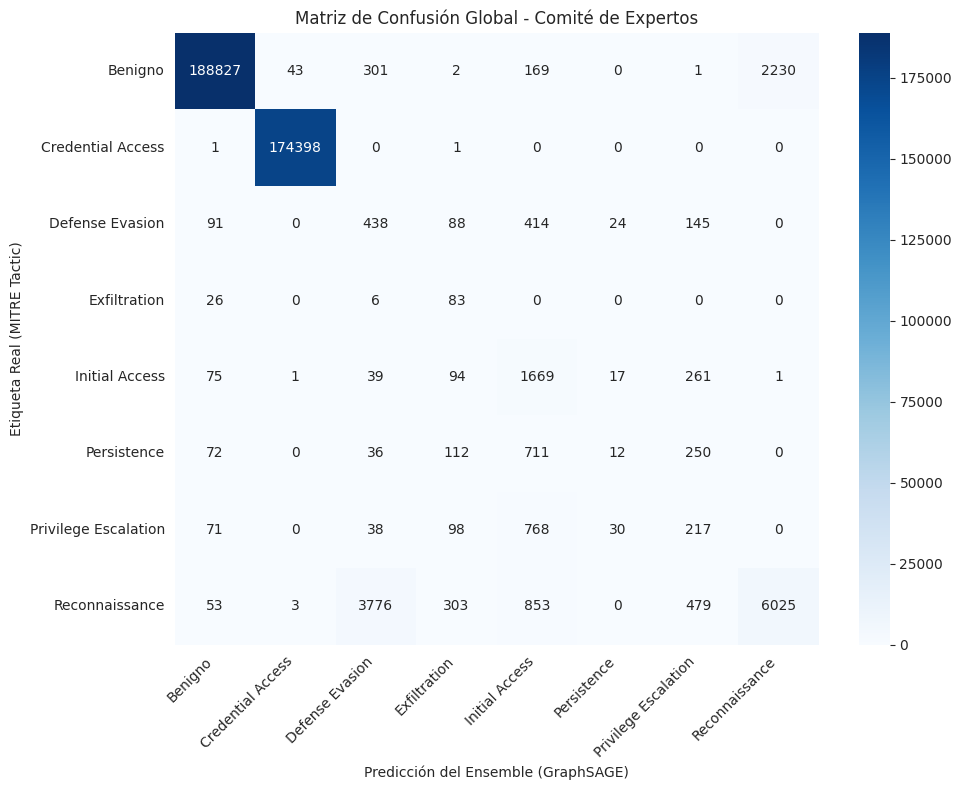

In [78]:
from sklearn.metrics import classification_report, confusion_matrix

model_web.eval()
model_infra.eval()
model_gen.eval()

print("Ejecutando Inferencia del Comité de Expertos...")

# Arrays para guardar TODAS las predicciones y etiquetas reales del conjunto de Test
todas_las_predicciones = []
todas_las_etiquetas = []

with torch.no_grad():
    # --- 1. INFERENCIA EXPERTO WEB ---
    if test_mask_web.sum() > 0:
        edge_index_test = edge_index_total[:, test_mask_web]
        edge_attr_test = edge_attr_total[test_mask_web].to(device)
        y_test = y_total[test_mask_web].to(device)
        
        out = model_web(x_nodos, edge_index_total, edge_index_test, edge_attr_test)
        preds = torch.argmax(out, dim=1)
        
        todas_las_predicciones.extend(preds.cpu().numpy())
        todas_las_etiquetas.extend(y_test.cpu().numpy())

    # --- 2. INFERENCIA EXPERTO INFRAESTRUCTURA ---
    if test_mask_infra.sum() > 0:
        edge_index_test = edge_index_total[:, test_mask_infra]
        edge_attr_test = edge_attr_total[test_mask_infra].to(device)
        y_test = y_total[test_mask_infra].to(device)
        
        out = model_infra(x_nodos, edge_index_total, edge_index_test, edge_attr_test)
        preds = torch.argmax(out, dim=1)
        
        todas_las_predicciones.extend(preds.cpu().numpy())
        todas_las_etiquetas.extend(y_test.cpu().numpy())

    # --- 3. INFERENCIA EXPERTO AUTENTICACIÓN ---
    if test_mask_auth.sum() > 0:
        edge_index_test = edge_index_total[:, test_mask_auth]
        edge_attr_test = edge_attr_total[test_mask_auth].to(device)
        y_test = y_total[test_mask_auth].to(device)
        
        out = model_auth(x_nodos, edge_index_total, edge_index_test, edge_attr_test)
        preds = torch.argmax(out, dim=1)
        
        todas_las_predicciones.extend(preds.cpu().numpy())
        todas_las_etiquetas.extend(y_test.cpu().numpy())

    # --- 4. INFERENCIA EXPERTO GENERALISTA ---
    if test_mask_gen.sum() > 0:
        edge_index_test = edge_index_total[:, test_mask_gen]
        edge_attr_test = edge_attr_total[test_mask_gen].to(device)
        y_test = y_total[test_mask_gen].to(device)
        
        out = model_gen(x_nodos, edge_index_total, edge_index_test, edge_attr_test)
        preds = torch.argmax(out, dim=1)
        
        todas_las_predicciones.extend(preds.cpu().numpy())
        todas_las_etiquetas.extend(y_test.cpu().numpy())

    # # En lugar de usar argmax directamente:
    # out = model_gen(x_nodos, edge_index_total, edge_index_test, edge_attr_test)
    
    # # 1. Convertimos los logits crudos en probabilidades reales (0.0 a 1.0)
    # probabilidades = F.softmax(out, dim=1)
    
    # # 2. Inicializamos las predicciones con la clase de mayor probabilidad (el argmax clásico)
    # preds = torch.argmax(probabilidades, dim=1)
    
    # # 3. THRESHOLD TUNING (Ajuste de Umbral)
    # # Supongamos que la táctica 'Exfiltration' es la clase 3 y 'Defense Evasion' la 2.
    # # Si la red está más de un 15% segura de que es Exfiltration, forzamos la alarma.
    
    # clase_exfiltration = encoder_tactics.transform(['Exfiltration'])[0]
    # clase_defense = encoder_tactics.transform(['Defense Evasion'])[0]
    # clase_persistence = encoder_tactics.transform(['Persistence'])[0]
    # clase_privilege = encoder_tactics.transform(['Privilege Escalation'])[0]
    
    # umbral_alerta = 0.20 # 15% de confianza es suficiente para alertar
    
    # # Sobrescribimos la predicción si supera el umbral crítico
    # preds[probabilidades[:, clase_exfiltration] > umbral_alerta] = clase_exfiltration
    # preds[probabilidades[:, clase_defense] > umbral_alerta] = clase_defense
    # preds[probabilidades[:, clase_persistence] > umbral_alerta] = clase_persistence
    # preds[probabilidades[:, clase_privilege] > umbral_alerta] = clase_privilege
    
    # todas_las_predicciones.extend(preds.cpu().numpy())
    # todas_las_etiquetas.extend(y_test.cpu().numpy())

# Convertimos a arrays de numpy para scikit-learn
y_true_global = np.array(todas_las_etiquetas)
preds_global = np.array(todas_las_predicciones)

print("\n--- REPORTE DE EVALUACIÓN MULTICLASE (ENSEMBLE GLOBAL) ---")
clases_presentes = np.unique(np.concatenate((y_true_global, preds_global)))
nombres_clases = encoder_tactics.inverse_transform(clases_presentes)
nombres_clases_list = [str(c) for c in nombres_clases]

print(classification_report(y_true_global, preds_global, labels=clases_presentes, target_names=nombres_clases_list))

# Matriz de confusión Global
cm = confusion_matrix(y_true_global, preds_global, labels=clases_presentes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases_list, yticklabels=nombres_clases_list)
plt.ylabel('Etiqueta Real (MITRE Tactic)')
plt.xlabel('Predicción del Ensemble (GraphSAGE)')
plt.title('Matriz de Confusión Global - Comité de Expertos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exportar modelos (con pesos y codificadores)

In [71]:
import joblib
import os

print("Guardando el Comité de Expertos para Producción...")
# Creamos una carpeta para los artefactos del modelo
os.makedirs("modelos_produccion", exist_ok=True)

# 1. Guardamos los pesos de los modelos PyTorch
torch.save(model_web.state_dict(), "modelos_produccion/experto_web.pth")
torch.save(model_infra.state_dict(), "modelos_produccion/experto_infra.pth")
torch.save(model_auth.state_dict(), "modelos_produccion/experto_auth.pth")
torch.save(model_gen.state_dict(), "modelos_produccion/experto_gen.pth")

# 2. Guardamos los Scalers (Vital para que el compañero escale los datos igual que tú)
joblib.dump(scaler_edges, "modelos_produccion/scaler_edges.pkl")
joblib.dump(scaler_nodes, "modelos_produccion/scaler_nodos.pkl")

# 3. Guardamos el codificador de Tácticas (Para que Neo4j reciba 'Exfiltration', no un '3')
joblib.dump(encoder_tactics, "modelos_produccion/encoder_tactics.pkl")

# 4. Guardamos las Features Inductivas de los Nodos (El "Cerebro" histórico)
# El compañero necesita saber cómo se comportan las IPs históricamente.
# Guardamos el DataFrame de nodos original (x_nodos) con sus IPs como índice.
node_df.to_pickle("modelos_produccion/node_features_historicas.pkl")

print("¡Modelos y artefactos exportados correctamente en la carpeta 'modelos_produccion'!")

Guardando el Comité de Expertos para Producción...
¡Modelos y artefactos exportados correctamente en la carpeta 'modelos_produccion'!


### Limpiar caché

In [72]:
import gc
gc.collect()
torch.cuda.empty_cache()